# 📊 Student Performance — Exploratory Data Analysis (EDA)
**Project:** Student Exam Score Prediction  
**Dataset:** Students Performance in Exams  
**Author:** Shonesh Rawat  
**Date:** 2026  

## 1. 📌 Project Overview

This notebook presents a comprehensive **Exploratory Data Analysis (EDA)** on the **Student Performance Dataset**. The goal is to uncover patterns, relationships, and insights that influence student scores in Math, Reading, and Writing.

The analysis will help us understand:
- How **demographic** and **socio-economic** factors affect academic performance
- The impact of **test preparation** and **lunch type** on scores
- Correlation between the three subject scores
- Feature importance hints before building a predictive ML model

## 2. 🧩 Problem Statement

This project aims to **predict students' academic performance** (math, reading, and writing scores) based on various demographic and socio-economic factors.

**Target Variables:**
- `math_score`
- `reading_score`
- `writing_score`

**Feature Variables:**

| Feature | Type | Description |
|---|---|---|
| `gender` | Categorical | Student's gender (male / female) |
| `race_ethnicity` | Categorical | Ethnic group (group A to E) |
| `parental_level_of_education` | Categorical | Highest education level of parents |
| `lunch` | Categorical | Standard or free/reduced lunch |
| `test_preparation_course` | Categorical | Whether student completed a prep course |

**Key Questions to Explore:**
- Does gender impact exam scores?
- Does parental education level influence student performance?
- Does test preparation course help students score better?
- Which features have the strongest correlation with student scores?

## 3. 📦 Import Libraries

We import all the necessary libraries for data manipulation and visualization.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

## 4. 📂 Load the Dataset

We load the dataset and take a first look at its structure.

In [2]:
df = pd.read_csv('../data/raw/stud.csv')

## 5. 🔍 Basic Data Inspection

In this section, we inspect the fundamental properties of the dataset:
- Shape (rows × columns)
- Column names and data types
- First & last few rows
- Missing values
- Duplicate records
- Summary statistics

### 5.1 First Look at the Data

In [3]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


### 5.2 📐 Dataset Shape
The dataset contains **1,000 rows** and **8 columns** — 5 categorical features and 3 numerical target score columns.

In [4]:
df.shape

(1000, 8)

### 5.3 🏷️ Data Types
- **Categorical (object):** `gender`, `race_ethnicity`, `parental_level_of_education`, `lunch`, `test_preparation_course`
- **Numerical (int64):** `math_score`, `reading_score`, `writing_score`

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


### 5.4 ✅ Missing Values

In [6]:
df.isnull().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

> ✅ No missing values found. The dataset is clean and requires no imputation.

### 5.5 Duplicate Records
Let's check if the dataset contains any duplicate rows.

In [7]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


> ✅ No duplicate rows found. Each record in the dataset is unique.

### 5.6 📊 Summary Statistics
Let's look at the key statistical measures for the three numerical score columns — mean, standard deviation, min, max, and quartiles.

In [8]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


> 💡 **Observation:** Reading and Writing scores tend to be slightly higher on average than Math scores. The minimum math score of 0 is noteworthy and may represent an outlier or data quality issue.

## 6. 📊 Univariate Analysis
We analyze each feature individually to understand its distribution and frequency.

### 6.1 Categorical Features
Let's check the value counts for each categorical column.

In [9]:
# gender
df['gender'].value_counts()

gender
female    518
male      482
Name: count, dtype: int64

> 💡 Dataset is nearly balanced — 518 females (51.8%) vs 482 males (48.2%).

In [10]:
# Race / Ethnicity
df['race_ethnicity'].value_counts()

race_ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64

> 💡 Group C is the largest group (31.9%). Group A is the smallest (8.9%).

In [11]:
# parental_level_of_education
df['parental_level_of_education'].value_counts()

parental_level_of_education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

> 💡 Most parents have "some college" or an associate's degree. Only 5.9% hold a master's degree.

In [12]:
# Lunch
df['lunch'].value_counts()

lunch
standard        645
free/reduced    355
Name: count, dtype: int64

> 💡 64.5% of students have standard lunch — this may act as a proxy for socio-economic status.

In [13]:
# test_preparation_course
df['test_preparation_course'].value_counts()

test_preparation_course
none         642
completed    358
Name: count, dtype: int64

> 💡 64.2% of students did NOT complete the test preparation course — an important factor to explore vs scores.

### 6.2 Numerical Features — Score Distributions

The three score columns — `math_score`, `reading_score`, and `writing_score` — are analyzed for their distributions.

> 💡 **Observations:**
> - All three scores follow an approximately **normal distribution**.
> - **Reading and Writing scores** tend to be slightly higher and more closely correlated with each other.
> - **Math scores** have the lowest mean (66.09) and show a slightly wider spread.
> - A small number of students scored **0 in math**, which should be investigated further as potential outliers.

In [14]:
df[['math_score','reading_score','writing_score']].describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


> 💡 Reading and writing scores have a higher mean than math. The minimum math score of 0 is suspicious.

### Distribution Plot — Math Score

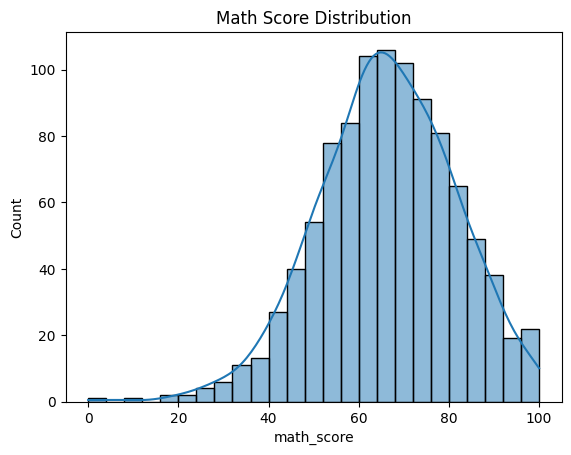

In [15]:
sns.histplot(df['math_score'],kde=True)
plt.title('Math Score Distribution')
plt.show()

### Distribution Plot — Reading Score

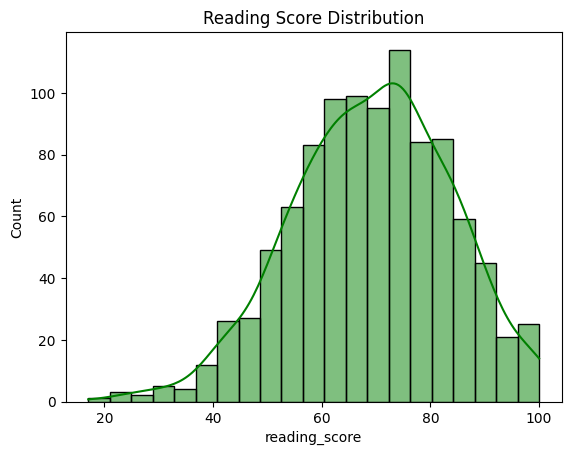

In [16]:
sns.histplot(df['reading_score'],kde=True,color='green')
plt.title('Reading Score Distribution')
plt.show()

### Distribution Plot — Writing Score

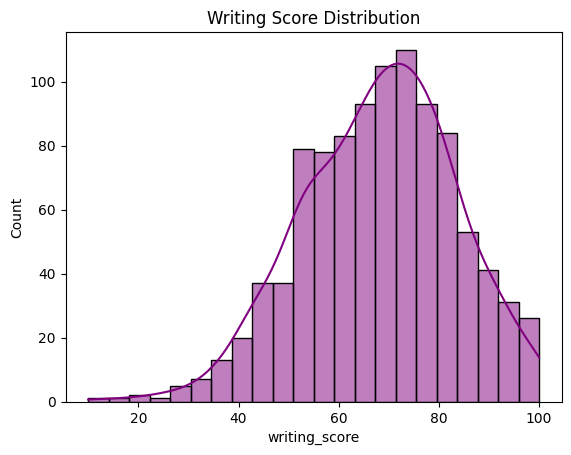

In [17]:
sns.histplot(df['writing_score'],kde=True,color='purple')
plt.title('Writing Score Distribution')
plt.show()

### All Three Score Distributions — Side by Side

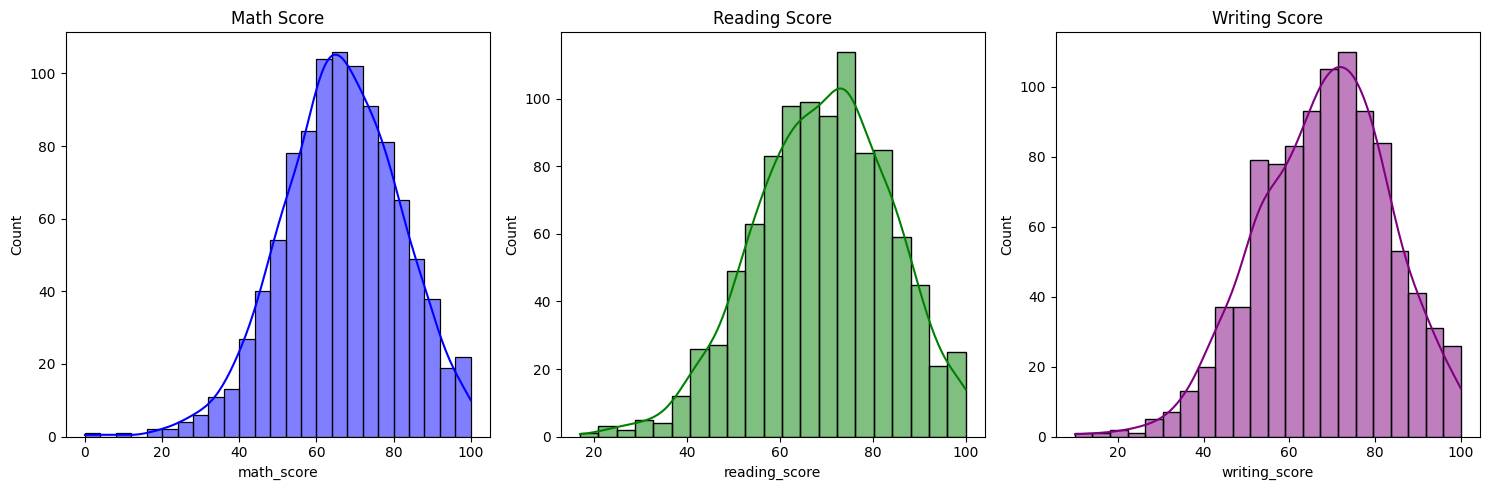

In [18]:

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, color in zip(axes, ['math_score', 'reading_score', 'writing_score'], ['blue', 'green', 'purple']):
    sns.histplot(df[col], kde=True, color=color, ax=ax)
    
axes[0].set_title('Math Score')
axes[1].set_title('Reading Score')
axes[2].set_title('Writing Score')

plt.tight_layout()
plt.show()

> 💡 All three scores are approximately normally distributed. Reading and writing scores are more closely aligned with each other than with math scores.

## 7. 🔗 Bivariate Analysis
We explore the relationship between each feature and the score columns to understand what factors influence student performance.

### 7.1 Gender vs. Scores
Let's compare average scores between male and female students.

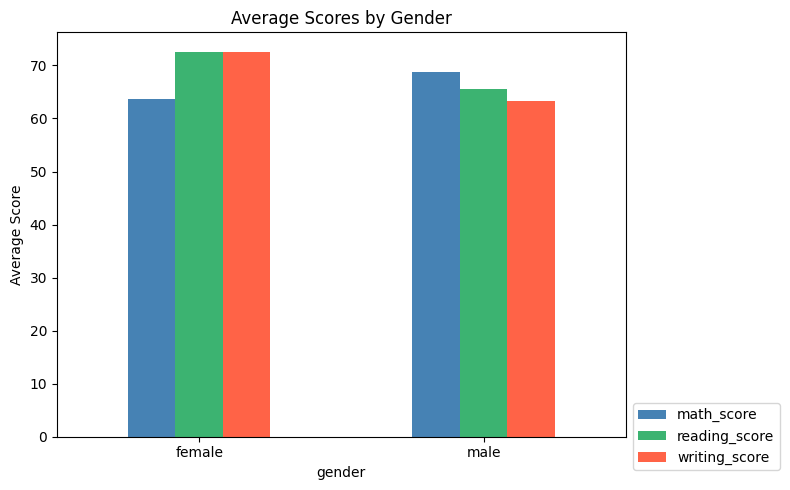

In [19]:
df.groupby('gender')[['math_score','reading_score','writing_score']].mean().plot(kind='bar',figsize=(8,5), color=['steelblue','mediumseagreen','tomato'])
plt.title('Average Scores by Gender')
plt.ylabel('Average Score')
plt.xticks(rotation=0)
plt.legend(loc='lower left', bbox_to_anchor=(1,-0.1))
plt.tight_layout()
plt.show()

> 💡 **Observation:** Female students score higher on average in reading and writing, while male students score slightly higher in math. This pattern is consistent with broader educational research.

### 7.2 Race/Ethnicity vs. Scores
Let's examine how scores vary across ethnic groups.

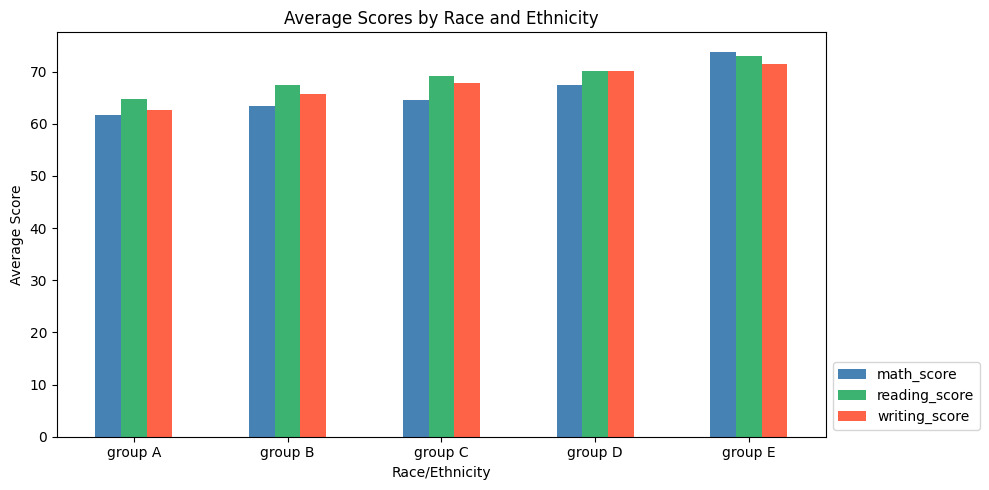

In [20]:
df.groupby('race_ethnicity')[['math_score','reading_score','writing_score']].mean().plot(kind='bar',figsize=(10,5), color=['steelblue','mediumseagreen','tomato'])
plt.title("Average Scores by Race and Ethnicity")
plt.xlabel("Race/Ethnicity")
plt.ylabel('Average Score')
plt.xticks(rotation=0)
plt.legend(loc='lower left',bbox_to_anchor=(1,0))
plt.tight_layout()
plt.show()

> 💡 **Observation:** Group E consistently achieves the highest average scores across all three subjects. Group A shows the lowest average scores. There is a clear performance gradient from Group A → Group E.

### 7.3 Parental Level of Education vs. Scores
Does a parent's education level influence their child's academic performance?

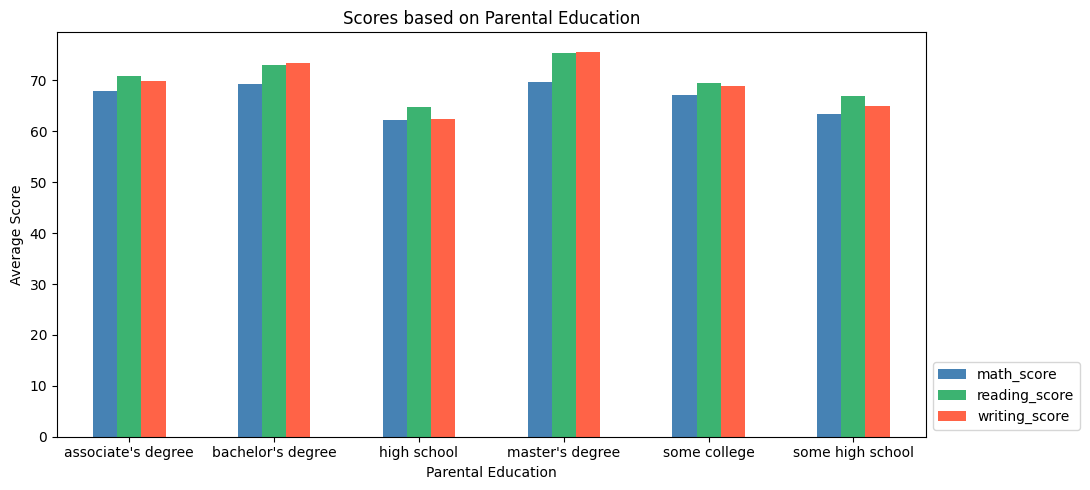

In [21]:
df.groupby('parental_level_of_education')[['math_score','reading_score','writing_score']].mean().plot(kind='bar',figsize=(11,5), color=['steelblue','mediumseagreen','tomato'])
plt.title("Scores based on Parental Education")
plt.xlabel('Parental Education')
plt.ylabel('Average Score')
plt.xticks(rotation=0)
plt.legend(loc='lower left',bbox_to_anchor=(1,0))
plt.tight_layout()
plt.show()

> 💡 **Observation:** Students whose parents hold a bachelor's or master's degree consistently score higher across all subjects. Students with parents who only completed "some high school" tend to have the lowest average scores. Parental education is a strong predictor of student performance.

### 7.4 Lunch Type vs. Scores
Let's compare performance between students on standard vs. free/reduced lunch plans.

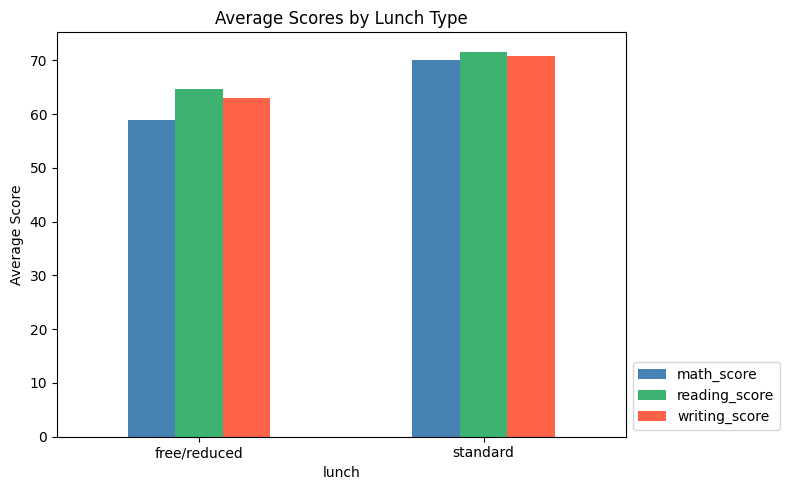

In [22]:
df.groupby('lunch')[['math_score','reading_score','writing_score']].mean().plot(kind='bar', figsize=(8,5), color=['steelblue','mediumseagreen','tomato'])
plt.title('Average Scores by Lunch Type')
plt.ylabel('Average Score')
plt.xticks(rotation=0)
plt.legend(loc='lower left',bbox_to_anchor=(1,0))
plt.tight_layout()
plt.show()

> 💡 **Observation:** Students on a standard lunch plan significantly outperform those on a free/reduced lunch plan across all three subjects. Lunch type likely serves as a proxy for socio-economic status.

### 7.5 Test Preparation Course vs. Scores
Did completing the test preparation course help students perform better?

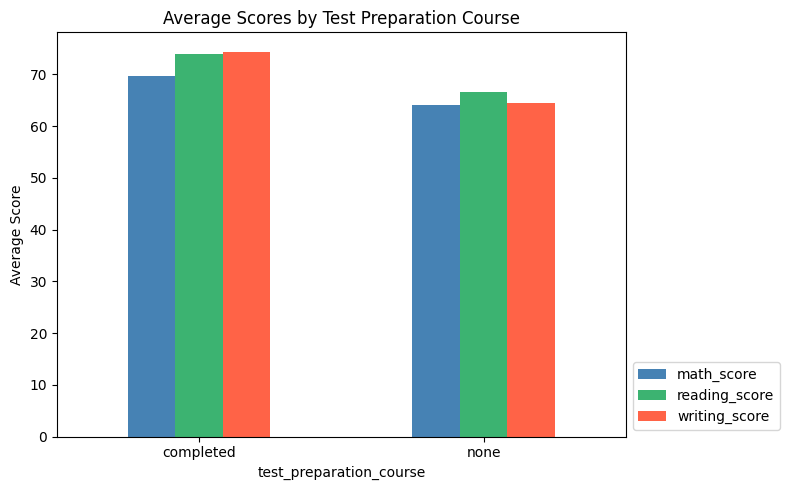

In [23]:
df.groupby('test_preparation_course')[['math_score','reading_score','writing_score']].mean().plot(kind='bar', figsize=(8,5), color=['steelblue','mediumseagreen','tomato'])
plt.title('Average Scores by Test Preparation Course')
plt.ylabel('Average Score')
plt.xticks(rotation=0)
plt.legend(loc='lower left',bbox_to_anchor=(1,0))
plt.tight_layout()
plt.show()

> 💡 **Observation:** Students who completed the test preparation course score noticeably higher in all three subjects. The improvement is most visible in reading and writing. This strongly suggests the test prep course has a positive impact on performance.

## 8. 🔥 Multivariate Analysis
We now look at relationships between multiple variables simultaneously.

### 8.1 Correlation Heatmap
Let's examine pairwise correlations between the three numerical score columns.

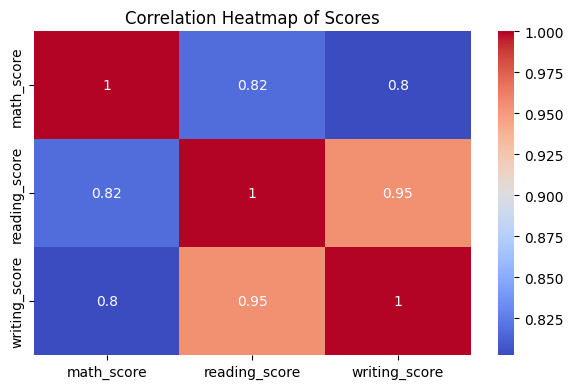

In [24]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['math_score','reading_score','writing_score']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Scores')
plt.tight_layout()
plt.show()

> 💡 **Observation:** `reading_score` and `writing_score` have the strongest correlation (~0.95), meaning students who read well also tend to write well. `math_score` correlates moderately with both (~0.82 with reading, ~0.80 with writing). All three are positively correlated.

### 8.2 Pairplot — Scores by Gender
A pairplot gives a full view of all pairwise score relationships, colored by gender.

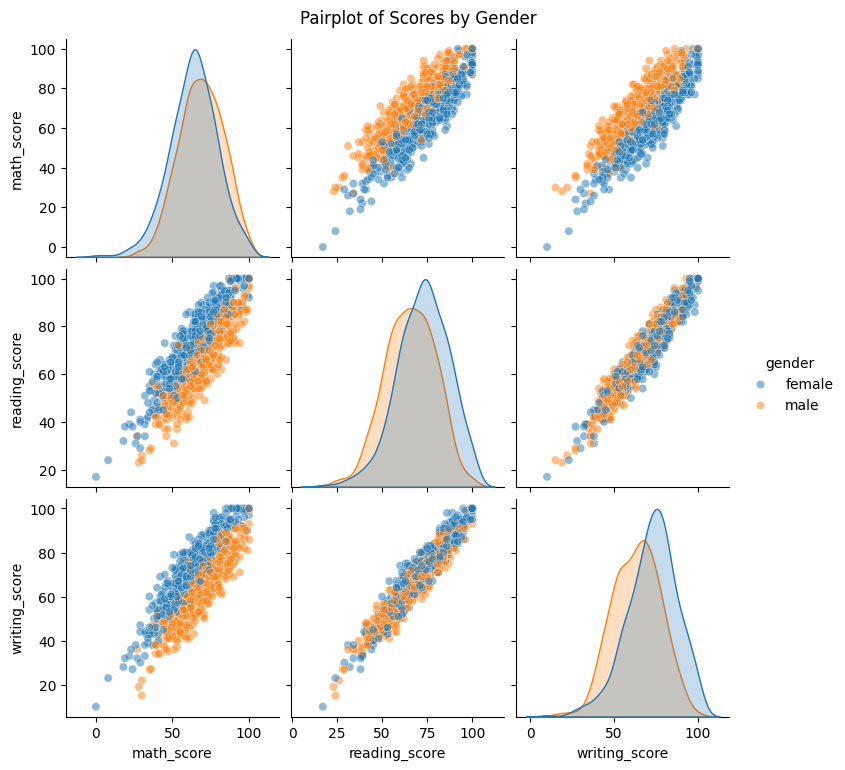

In [25]:
sns.pairplot(df[['math_score','reading_score','writing_score','gender']], hue='gender', plot_kws={'alpha': 0.5})
plt.suptitle('Pairplot of Scores by Gender', y=1.02)
plt.show()

> 💡 **Observation:** The distributions largely overlap, but the gender-based split in math vs. reading/writing is visible. A small number of extreme low-end outliers are visible across all three score columns.

### 8.3 Combined Effect: Lunch Type + Test Prep → Scores
Let's look at how the combination of lunch type and test preparation affects average scores.

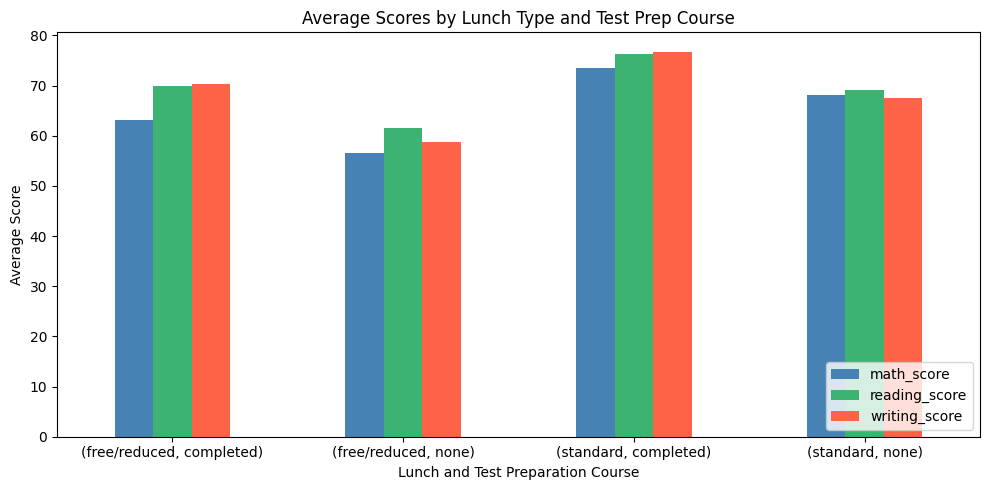

In [26]:
df.groupby(['lunch','test_preparation_course'])[['math_score','reading_score','writing_score']].mean().plot(kind='bar', figsize=(10,5), color=['steelblue','mediumseagreen','tomato'])
plt.title('Average Scores by Lunch Type and Test Prep Course')
plt.ylabel('Average Score')
plt.xlabel('Lunch and Test Preparation Course')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

> 💡 **Observation:** Students with standard lunch AND a completed test prep course consistently achieve the highest scores. Students with free/reduced lunch AND no test prep show the lowest performance. Both factors appear to have an additive positive effect on student scores.

## 9. 🚨 Outlier Detection
We use box plots to visually detect outliers in the three numerical score columns.

### 9.1 Box Plots — Score Distributions

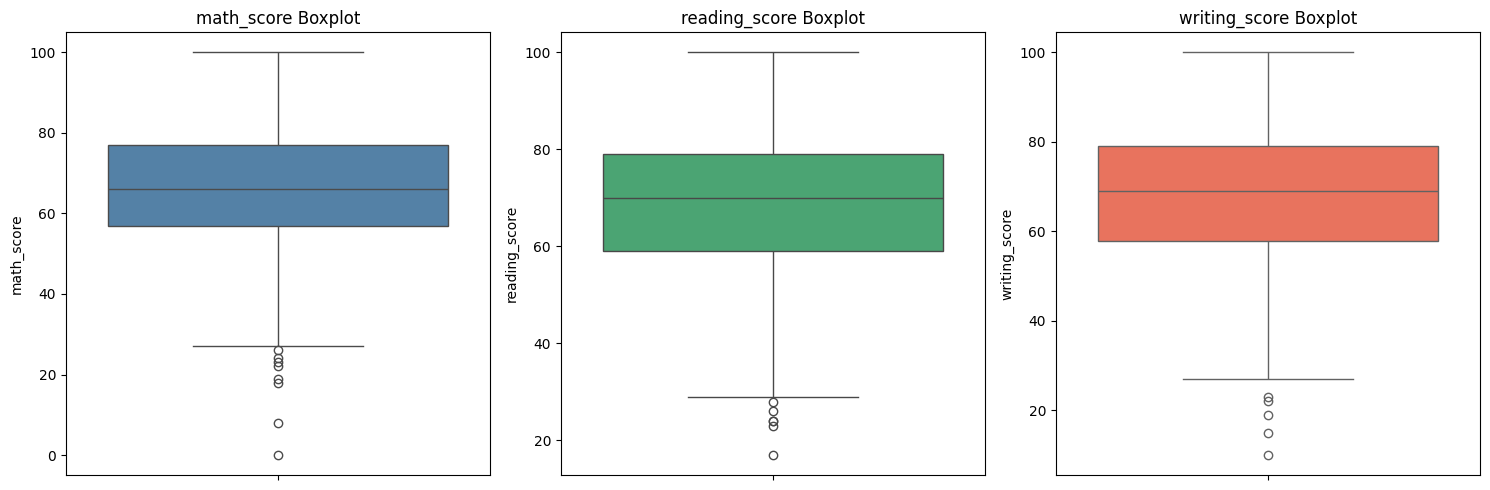

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, color in zip(axes, ['math_score', 'reading_score', 'writing_score'], ['steelblue', 'mediumseagreen', 'tomato']):
    sns.boxplot(y=df[col], color=color, ax=ax)
    ax.set_title(f'{col} Boxplot')

plt.tight_layout()
plt.show()

> 💡 **Observation:** A small number of students scored 0 in math, which is unusually low and may represent students who did not attempt the exam. Some very low scores in reading (min: 17) and writing (min: 10) are also present. These form a very small portion of the data — we will retain them but keep them in mind during modeling.

### 9.2 Outlier Count using IQR Method
Let's quantify outliers using the Interquartile Range (IQR) method.

In [28]:
for col in ['math_score', 'reading_score', 'writing_score']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers (lower bound: {lower}, upper bound: {upper})")

math_score: 8 outliers (lower bound: 27.0, upper bound: 107.0)
reading_score: 6 outliers (lower bound: 29.0, upper bound: 109.0)
writing_score: 5 outliers (lower bound: 25.875, upper bound: 110.875)


> 💡 **Observation:** The IQR method confirms there are very few outliers. Since they represent a tiny fraction of 1000 records, we will keep them in the dataset rather than removing them, as they could represent genuine low-performing students.

## 10. ⚙️ Feature Engineering
Based on our EDA insights, we now create new features and prepare the dataset for machine learning model building.

### 10.1 Create Total Score & Average Score
Since all three scores are highly correlated (~0.80+), we create a combined `total_score` and `average_score` column that can serve as a single regression target.

In [29]:
df['total_score'] = df['reading_score'] + df['writing_score'] + df['math_score']
df['average_score'] = (df['total_score']/3).round(2)
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.67
1,female,group C,some college,standard,completed,69,90,88,247,82.33
2,female,group B,master's degree,standard,none,90,95,93,278,92.67
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.33
4,male,group C,some college,standard,none,76,78,75,229,76.33


> 💡 `average_score` can be used as a single target variable for regression modeling instead of predicting three separate scores.

### 10.2 Create Performance Category
We bin the `average_score` into labeled performance categories for classification modeling.

In [30]:
df['performance'] = pd.cut(df['average_score'],
                            bins=[0, 40, 60, 80, 100],
                            labels=['Poor', 'Average', 'Good', 'Excellent'])
df['performance'].value_counts()

performance
Good         513
Average      261
Excellent    194
Poor          32
Name: count, dtype: int64

> 💡 This categorical column can be used as a target variable for **classification** models (e.g., predicting which performance band a student falls into).

## 11. 💡 Key Insights & Conclusions

### Summary of Findings

| Factor | Impact on Scores |
|---|---|
| **Gender** | Females score higher in reading & writing; males slightly higher in math |
| **Parental Education** | Higher parental education → consistently higher student scores |
| **Lunch Type** | Standard lunch students significantly outperform free/reduced lunch students |
| **Test Prep Course** | Completing the course positively boosts all three scores |
| **Race/Ethnicity** | Group E performs best; Group A performs lowest on average |

### Key Takeaways

1. **Socio-economic factors** (lunch type, parental education) play a **strong role** in student performance.
2. **Test preparation** has a measurable, positive impact — especially on reading and writing.
3. **Reading and writing scores** are highly correlated and may be treated similarly during modeling.
4. The dataset is **clean** — no missing values, well-balanced categories, and approximately normal score distributions.
5. A **composite average score** and **performance category** were engineered from the three individual scores — ready for regression and classification modeling.

### Next Steps 🚀

- **Model Building:** Preprocessing (encoding, scaling) and model training covered in `model_training.ipynb`. Models to try: Linear Regression, Ridge/Lasso, Decision Tree, Random Forest, XGBoost.
- **Evaluation Metrics:** Use RMSE, MAE, and R² to evaluate regression performance.
- **Hyperparameter Tuning:** Optimize the best-performing model using GridSearchCV or RandomizedSearchCV.